# 02 - EDA exploratorio

Este notebook inicia el analisis exploratorio del dataset de reservas hoteleras. El objetivo es entender la calidad de los datos, las distribuciones principales y la relacion inicial entre las variables y el target `booking_status`.

Este notebook aun no entrena modelos. Su funcion es ayudarnos a decidir como preparar los datos antes del baseline.

## 1. Preguntas guia del EDA

- Hay nulos o duplicados?
- El target esta balanceado?
- Que variables numericas tienen distribuciones raras u outliers?
- Que variables categoricas tienen muchas categorias?
- Que variables parecen relacionarse con la cancelacion?
- Hay columnas que debamos excluir o transformar antes del modelo?

## 2. Importacion de librerias

Usaremos `pandas` para manipular datos, `matplotlib` y `seaborn` para visualizar. Estas visualizaciones seran simples y orientadas a entender el dataset.

In [ ]:
%pip install -r ../requirements.txt


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

## 3. Carga del dataset

Leemos el archivo original desde `data/raw/`. En EDA podemos explorar, pero evitamos modificar el archivo crudo.

In [3]:
DATA_PATH = Path("../data/raw/hotel-reservations-classification-dataset/Hotel Reservations.csv")
TARGET = "booking_status"

df = pd.read_csv(DATA_PATH)
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


## 4. Revision general

Primero confirmamos dimensiones, columnas y tipos. Esta revision sirve para detectar si el archivo cargado coincide con lo esperado en la SPEC.

In [4]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.info()

Filas: 36275
Columnas: 19
<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  

Interpretacion confirmada:

- El archivo cargado coincide con lo esperado: 36.275 filas y 19 columnas.
- La columna `booking_status` esta presente y mantiene las dos clases del problema: reserva cancelada y no cancelada.
- Los tipos detectados por pandas permiten separar las variables en numericas, categoricas y binarias sin conversiones complejas en esta etapa.
- `Booking_ID` funciona como identificador tecnico de la reserva, por lo que no debe usarse como feature para entrenar el modelo.


## 5. Nulos y duplicados

Los nulos pueden requerir imputacion. Los duplicados pueden inflar artificialmente el rendimiento del modelo si no se revisan.

In [5]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [6]:
duplicated_rows = df.duplicated().sum()
print(f"Filas duplicadas exactas: {duplicated_rows}")

Filas duplicadas exactas: 0


Interpretacion confirmada:

- No se detectan valores nulos en ninguna columna. Esto simplifica el baseline porque no hace falta imputacion inicial.
- No se detectan filas duplicadas exactas, asi que por ahora no hay que eliminar duplicados antes del split.
- Aunque la calidad basica es buena, el preprocessing seguira siendo necesario para codificar variables categoricas, separar correctamente train/validacion/test y evitar leakage.


## 6. Distribucion del target

Esta grafica muestra cuantas reservas fueron canceladas y cuantas no. Es importante porque una clase mayoritaria puede hacer que `accuracy` sea enganosa.

,count,percentage
booking_status,,
Not_Canceled,24390,67.24
Canceled,11885,32.76


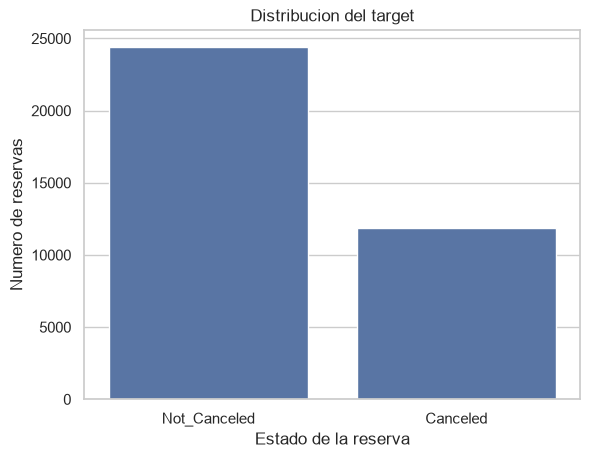

In [7]:
target_counts = df[TARGET].value_counts()
target_percentages = df[TARGET].value_counts(normalize=True).mul(100).round(2)

display(pd.DataFrame({"count": target_counts, "percentage": target_percentages}))

ax = sns.countplot(data=df, x=TARGET, order=target_counts.index)
ax.set_title("Distribucion del target")
ax.set_xlabel("Estado de la reserva")
ax.set_ylabel("Numero de reservas")
plt.show()

Interpretacion confirmada:

- `Not_Canceled` representa 24.390 reservas, aproximadamente 67.24% del dataset.
- `Canceled` representa 11.885 reservas, aproximadamente 32.76% del dataset.
- Hay desbalance moderado, pero no extremo.
- Una regla simple que siempre prediga la clase mayoritaria ya tendria una accuracy cercana al 67%, por eso `accuracy` sola puede ser enganosa.
- Para evaluar modelos necesitaremos mirar `precision`, `recall`, `F1-score`, ROC-AUC y matriz de confusion.


## 7. Separacion inicial de columnas

Separamos columnas numericas, categoricas, binarias y excluidas. Esta clasificacion inicial puede cambiar despues del EDA.

In [8]:
excluded_columns = ["Booking_ID"]

categorical_columns = [
    "type_of_meal_plan",
    "room_type_reserved",
    "market_segment_type",
]

binary_columns = [
    "required_car_parking_space",
    "repeated_guest",
]

numeric_columns = [
    "no_of_adults",
    "no_of_children",
    "no_of_weekend_nights",
    "no_of_week_nights",
    "lead_time",
    "arrival_year",
    "arrival_month",
    "arrival_date",
    "no_of_previous_cancellations",
    "no_of_previous_bookings_not_canceled",
    "avg_price_per_room",
    "no_of_special_requests",
]

print(f"Numericas: {len(numeric_columns)}")
print(f"Categoricas: {len(categorical_columns)}")
print(f"Binarias: {len(binary_columns)}")
print(f"Excluidas: {excluded_columns}")

Numericas: 12
Categoricas: 3
Binarias: 2
Excluidas: ['Booking_ID']


Interpretacion inicial:

- Se identifican 12 variables numericas, 3 categoricas, 2 binarias y 1 columna excluida.
- Las variables categoricas tienen baja cardinalidad, por lo que `OneHotEncoder` es una opcion razonable para el primer baseline.
- Las variables numericas pueden requerir escalado si usamos modelos sensibles a escala, como Logistic Regression.
- Las variables binarias ya estan codificadas como 0/1 y pueden pasar directamente al modelo inicial.
- `Booking_ID` queda fuera para evitar que el modelo memorice identificadores sin valor predictivo real.


## 8. Estadisticos de variables numericas

Con `describe()` revisamos media, desviacion, minimos, maximos y percentiles. Esto ayuda a detectar rangos raros u outliers.

In [9]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
no_of_previous_cancellations,36275.0,0.023349,0.368331,0.0,0.0,0.00,0.0,13.0
no_of_previous_bookings_not_canceled,36275.0,0.153411,1.754171,0.0,0.0,0.00,0.0,58.0


Interpretacion confirmada:

- No aparecen valores negativos en las variables numericas revisadas.
- `lead_time` tiene un rango amplio, desde 0 hasta 443 dias, por lo que puede aportar mucha senal pero tambien generar sensibilidad a outliers.
- `avg_price_per_room` va de 0 a 540. Los valores extremos y los ceros deben revisarse antes de decidir si se transforman o se mantienen.
- Varias variables historicas, como `no_of_previous_cancellations` y `no_of_previous_bookings_not_canceled`, concentran la mayoria de registros en cero. No deben eliminarse automaticamente, pero conviene tratarlas como variables muy asimetricas.
- `no_of_adults` contiene algunos registros con valor 0; no se eliminan en EDA, pero quedan marcados para revisar si representan reservas especiales o datos inconsistentes.


## 9. Distribuciones numericas principales

Visualizamos algunas variables numericas para entender su forma. No buscamos aun conclusiones finales, solo patrones iniciales.

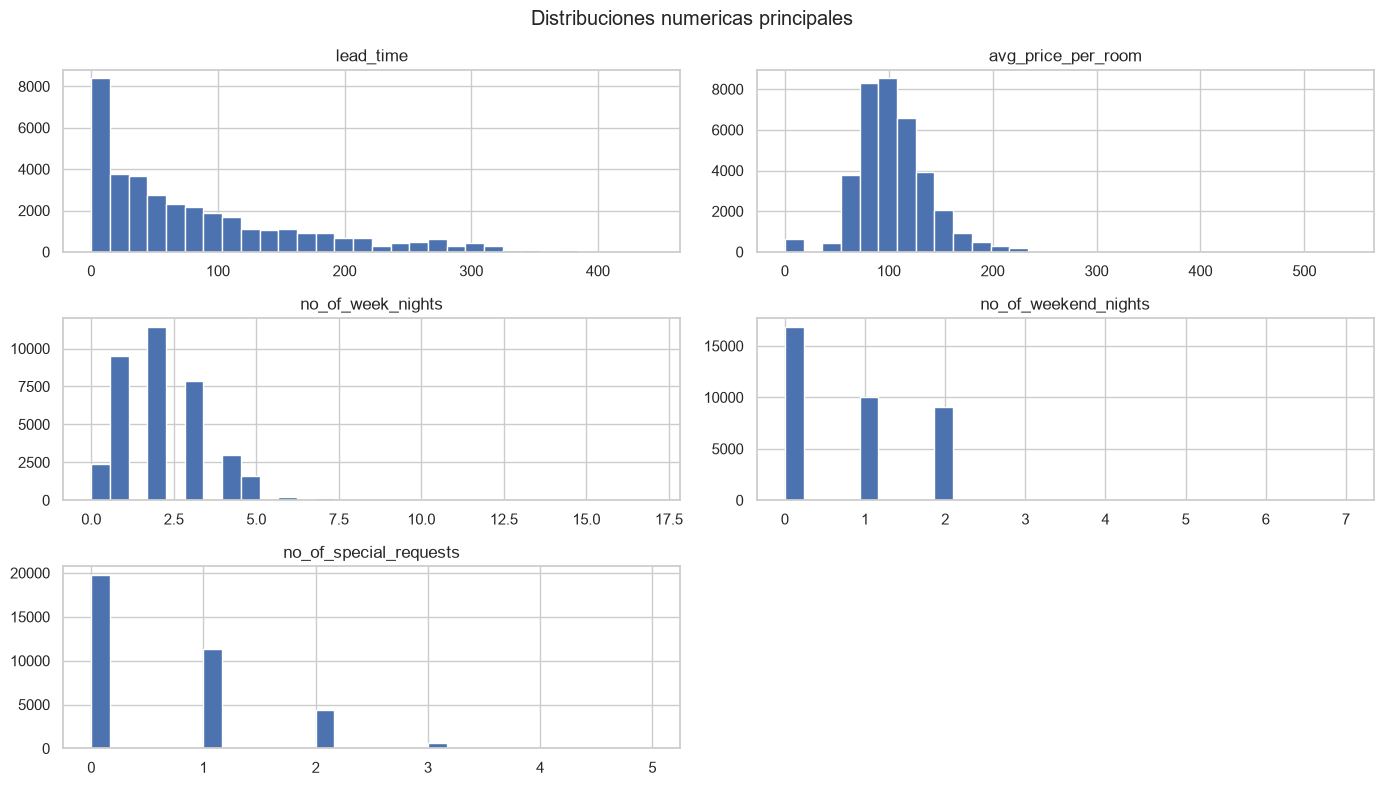

In [10]:
selected_numeric = [
    "lead_time",
    "avg_price_per_room",
    "no_of_week_nights",
    "no_of_weekend_nights",
    "no_of_special_requests",
]

df[selected_numeric].hist(figsize=(14, 8), bins=30)
plt.suptitle("Distribuciones numericas principales")
plt.tight_layout()
plt.show()

Interpretacion confirmada:

- `lead_time` muestra una distribucion asimetrica: muchas reservas tienen anticipacion baja o media, pero existe una cola larga de reservas hechas con mucha antelacion.
- `avg_price_per_room` tambien presenta asimetria y algunos valores altos, por lo que el baseline debe ser robusto a rangos amplios.
- Las noches de estancia se concentran en valores bajos, aunque existen estancias mas largas que pueden influir en el comportamiento de cancelacion.
- `no_of_special_requests` concentra muchos ceros, pero esto puede ser informativo: una reserva sin solicitudes especiales podria comportarse distinto a una reserva con varias solicitudes.
- No se eliminan outliers en esta fase. Primero se mantendran y se evaluara su impacto en train/validacion.


## 10. Variables categoricas

Revisamos cuantas categorias tiene cada variable y si alguna categoria domina demasiado.

In [11]:
for column in categorical_columns:
    print(f"\n{column}")
    display(df[column].value_counts(dropna=False))


type_of_meal_plan


type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64


room_type_reserved


room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64


market_segment_type


market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

Interpretacion confirmada:

- Las variables categoricas tienen pocas categorias, por lo que One-Hot Encoding es suficiente para el primer baseline.
- Algunas categorias dominan claramente: `Meal Plan 1`, `Room_Type 1` y el segmento `Online` concentran gran parte de los registros.
- Tambien hay categorias muy raras, como `Meal Plan 3` y algunos tipos de habitacion con muy pocos casos. Estas categorias pueden generar columnas poco estables despues del encoding.
- Para el baseline conviene usar `handle_unknown='ignore'` en el encoder, de forma que el pipeline pueda predecir aunque aparezca una categoria no vista en validacion o produccion.


## 11. Relacion inicial con el target

Comparamos algunas variables contra `booking_status`. Este paso nos ayuda a detectar senales predictivas iniciales.

In [12]:
for column in categorical_columns + binary_columns:
    table = pd.crosstab(df[column], df[TARGET], normalize="index").round(3)
    print(f"\nProporcion por categoria: {column}")
    display(table)


Proporcion por categoria: type_of_meal_plan


booking_status,Canceled,Not_Canceled
type_of_meal_plan,,
Meal Plan 1,0.312,0.688
Meal Plan 2,0.456,0.544
Meal Plan 3,0.200,0.800
Not Selected,0.331,0.669



Proporcion por categoria: room_type_reserved


booking_status,Canceled,Not_Canceled
room_type_reserved,,
Room_Type 1,0.323,0.677
Room_Type 2,0.329,0.671
Room_Type 3,0.286,0.714
Room_Type 4,0.342,0.658
Room_Type 5,0.272,0.728
Room_Type 6,0.420,0.580
Room_Type 7,0.228,0.772



Proporcion por categoria: market_segment_type


booking_status,Canceled,Not_Canceled
market_segment_type,,
Aviation,0.296,0.704
Complementary,0.000,1.000
Corporate,0.109,0.891
Offline,0.299,0.701
Online,0.365,0.635



Proporcion por categoria: required_car_parking_space


booking_status,Canceled,Not_Canceled
required_car_parking_space,,
0,0.335,0.665
1,0.101,0.899



Proporcion por categoria: repeated_guest


booking_status,Canceled,Not_Canceled
repeated_guest,,
0,0.336,0.664
1,0.017,0.983


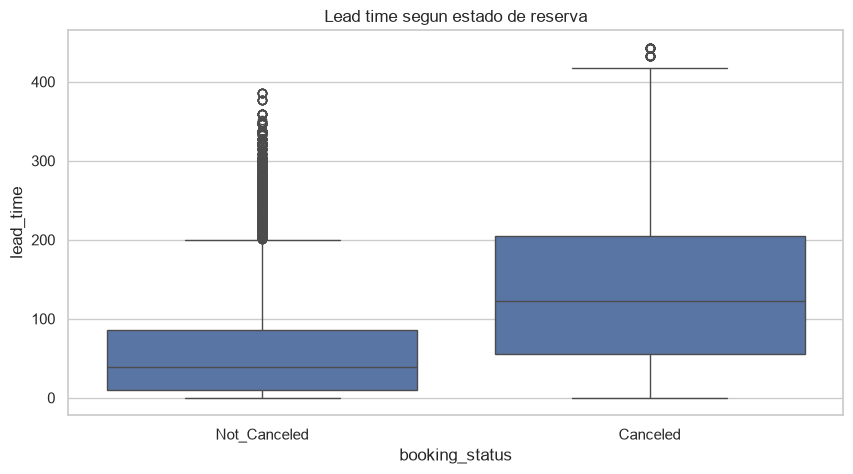

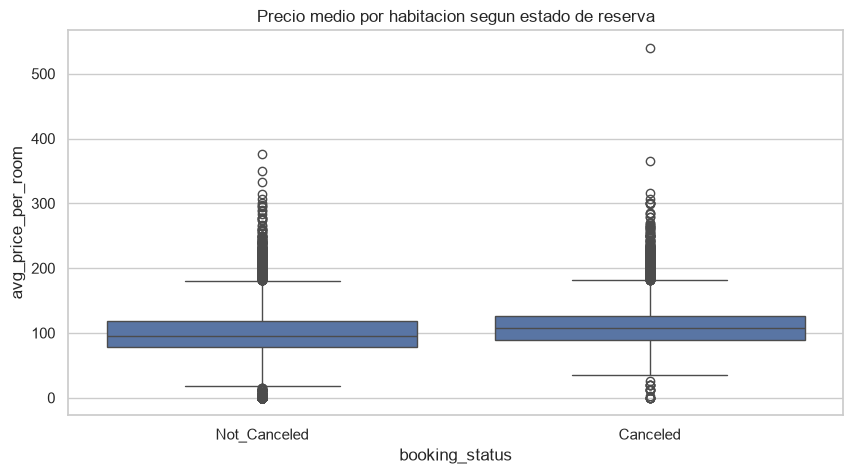

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x=TARGET, y="lead_time")
plt.title("Lead time segun estado de reserva")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x=TARGET, y="avg_price_per_room")
plt.title("Precio medio por habitacion segun estado de reserva")
plt.show()

Interpretacion confirmada:

- `lead_time` parece ser una de las variables mas relevantes: las reservas canceladas tienen una anticipacion media y mediana bastante mayor que las no canceladas.
- `avg_price_per_room` tambien es algo mayor en reservas canceladas, aunque la diferencia parece menos marcada que en `lead_time`.
- `no_of_special_requests` muestra una relacion inversa con cancelacion: las reservas con mas solicitudes especiales tienden a cancelarse menos.
- En variables categoricas, `market_segment_type` muestra diferencias relevantes: `Online` y `Offline` tienen tasas de cancelacion mayores que `Corporate`; `Complementary` no muestra cancelaciones, pero es un grupo pequeno y no debe sobreinterpretarse.
- `repeated_guest` tambien parece importante: los clientes repetidos cancelan mucho menos que los no repetidos.
- Estas relaciones son hipotesis predictivas, no conclusiones causales. El baseline y las metricas de validacion confirmaran cuales aportan valor real.


## 12. Correlacion numerica

La correlacion solo mide relaciones lineales entre variables numericas. No captura todas las relaciones posibles, pero ayuda a detectar redundancias iniciales.

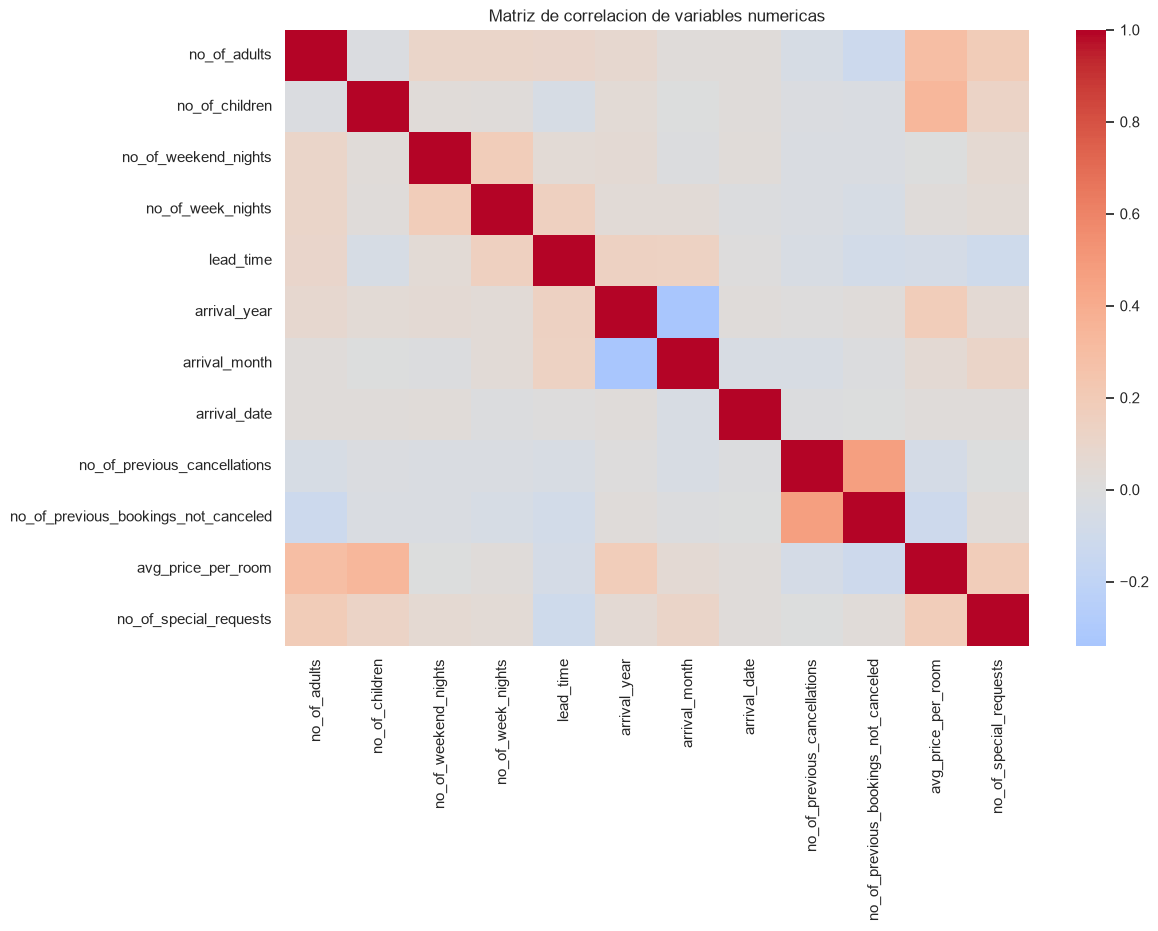

In [14]:
plt.figure(figsize=(12, 8))
corr = df[numeric_columns].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlacion de variables numericas")
plt.show()

Interpretacion confirmada:

- No se observan correlaciones extremadamente altas entre variables numericas, asi que no aparece una redundancia obvia que obligue a eliminar features antes del baseline.
- Las correlaciones mas visibles son moderadas, por ejemplo entre historico de cancelaciones y reservas previas no canceladas, o entre precio medio y cantidad de adultos/ninos.
- Una correlacion baja no significa que una variable sea inutil, especialmente en clasificacion, porque puede aportar informacion no lineal o interactuar con otras variables.
- Para el baseline mantendremos las variables numericas candidatas y dejaremos que las metricas de validacion indiquen si alguna no aporta valor.


## 13. Conclusiones del EDA exploratorio

Resumen final:

- Calidad general de datos: el dataset esta completo a nivel de nulos y no presenta duplicados exactos. Esto permite avanzar al baseline sin una fase pesada de limpieza inicial.
- Target: `booking_status` define un problema de clasificacion binaria con desbalance moderado. La clase `Not_Canceled` es mayoritaria, por lo que la evaluacion debe incluir metricas mas informativas que `accuracy`.
- Variables numericas relevantes: `lead_time`, `avg_price_per_room`, `no_of_special_requests` y las noches de estancia muestran patrones utiles para explorar en el modelo. `lead_time` destaca como una senal fuerte asociada a cancelacion.
- Outliers y asimetria: `lead_time`, `avg_price_per_room` y las variables historicas tienen distribuciones asimetricas o con muchos ceros. No se eliminaran automaticamente, pero el preprocessing debe ser robusto a estos rangos.
- Variables categoricas: tienen baja cardinalidad y pueden codificarse con One-Hot Encoding. Sin embargo, existen categorias raras que deben manejarse con cuidado para evitar columnas inestables.
- Columnas excluidas: `Booking_ID` debe eliminarse del entrenamiento porque es un identificador y podria introducir memorizacion sin valor predictivo real.
- Riesgos antes del preprocessing: leakage por ajustar transformaciones antes del split, sobreinterpretacion de categorias pequenas, desbalance del target y sensibilidad de algunos modelos a variables con escalas muy diferentes.

Estrategia sugerida para el preprocessing del baseline:

1. Separar `X` e `y`, codificando `booking_status` como variable binaria.
2. Eliminar `Booking_ID` antes de entrenar.
3. Crear split train/validacion/test estratificado para conservar la proporcion de clases.
4. Ajustar cualquier transformacion solo con train para evitar leakage.
5. Usar `ColumnTransformer`: One-Hot Encoding para categoricas, passthrough para binarias y escalado de numericas si el baseline es Logistic Regression.
6. Entrenar primero un baseline simple y compararlo contra un `DummyClassifier` de clase mayoritaria.
7. Evaluar con `accuracy`, `precision`, `recall`, `F1-score`, ROC-AUC, matriz de confusion y diferencia train-validacion para revisar overfitting.

Proximo paso despues de cerrar este EDA: implementar el pipeline de preprocessing para baseline.
